# **DATA SCIENCE**

# **Menyiapkan semua library yang dibutuhkan**

In [1]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import pandas as pd
import seaborn as sns
import tensorflow as tf
import cv2
import PIL
from pathlib import Path

### **Library Setup & Functions**

* **`os`** & **`Path`**: Navigasi folder dan manajemen *path* file dataset.
* **`numpy (np)`**: Mengolah gambar sebagai susunan angka (array).
* **`random`**: Mengacak urutan data agar model tidak bias.
* **`matplotlib (plt)`** & **`seaborn (sns)`**: Visualisasi gambar, grafik performa, dan matriks evaluasi.
* **`PIL` & `cv2` (OpenCV)**: *Preprocessing* gambar (buka, resize, manipulasi warna, & rotasi).
* **`pandas (pd)`**: Mengelola tabel data/label dataset.
* **`tensorflow (tf)`**: Framework utama untuk membangun dan melatih model Deep Learning.

---


# **Data Wrangling**

In [21]:
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Sampah'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
https://drive.google.com/drive/folders/1SUohhH4xsz3JLsNZDloHzbPd4QeB9swE

Proyek ini menggunakan **Garbage Classification V2**, sebuah dataset komprehensif yang disusun oleh **Suman Kunwar** melalui [Kaggle](https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2). Dataset ini merupakan benchmark citra multi-kelas yang dirancang untuk mendukung otomatisasi pemisahan sampah dan sistem daur ulang berbasis *computer vision*. Dengan cakupan kategori yang luas, data ini digunakan untuk melatih model *deep learning* agar mampu mengklasifikasikan jenis limbah secara akurat, guna menciptakan solusi teknologi yang lebih efisien dalam pengelolaan lingkungan.


Assesing Data

In [6]:
categories = os.listdir(dataset_path)
stats = []

for category in categories:
    path = os.path.join(dataset_path, category)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        stats.append({'Kategori': category, 'Jumlah': count})

df_stats = pd.DataFrame(stats)

total_images = df_stats['Jumlah'].sum()
print(f"Total seluruh gambar sampah: {total_images}")
print("-" * 30)
print(df_stats.sort_values(by='Jumlah', ascending=False))


Total seluruh gambar sampah: 12259
------------------------------
     Kategori  Jumlah
2     clothes    1892
0       glass    1736
5     plastic    1597
6       shoes    1449
1   cardboard    1411
4       paper    1336
3       metal     930
7     battery     756
9  biological     699
8       trash     453


Dataset ini mencakup **12.259 gambar** dengan sebaran yang **tidak seimbang (imbalance)**, di mana kategori *clothes* mendominasi sementara kategori *trash* sangat minim.

---

# **Exploratory Data Analysis (EDA)**

In [8]:
stats = []
for category in os.listdir(dataset_path):
    path = os.path.join(dataset_path, category)
    if os.path.isdir(path):
        count = len(os.listdir(path))
        stats.append({'Kategori': category, 'Jumlah Gambar': count})

df_stats = pd.DataFrame(stats)

total_data = df_stats['Jumlah Gambar'].sum()
paling_banyak = df_stats.loc[df_stats['Jumlah Gambar'].idxmax()]
paling_sedikit = df_stats.loc[df_stats['Jumlah Gambar'].idxmin()]
rata_rata = df_stats['Jumlah Gambar'].mean()

print(f"--- RINGKASAN DATASET ---")
print(f"Total Seluruh Gambar : {total_data}")
print(f"Rata-rata per Kelas  : {rata_rata:.2f}")
print(f"Data Terbanyak       : {paling_banyak['Kategori']} ({paling_banyak['Jumlah Gambar']} gambar)")
print(f"Data Tersedikit      : {paling_sedikit['Kategori']} ({paling_sedikit['Jumlah Gambar']} gambar)")

--- RINGKASAN DATASET ---
Total Seluruh Gambar : 12259
Rata-rata per Kelas  : 1225.90
Data Terbanyak       : clothes (1892 gambar)
Data Tersedikit      : trash (453 gambar)


Dataset ini terdiri dari **12.259 gambar** dengan sebaran yang **tidak seimbang (*imbalance*)**, di mana kategori *clothes* (1.892) sangat mendominasi dibandingkan kategori *trash* (453).

# **DATA VISUALIZATION**

**Sampel Dataset Sampah**

Found 12259 files belonging to 10 classes.


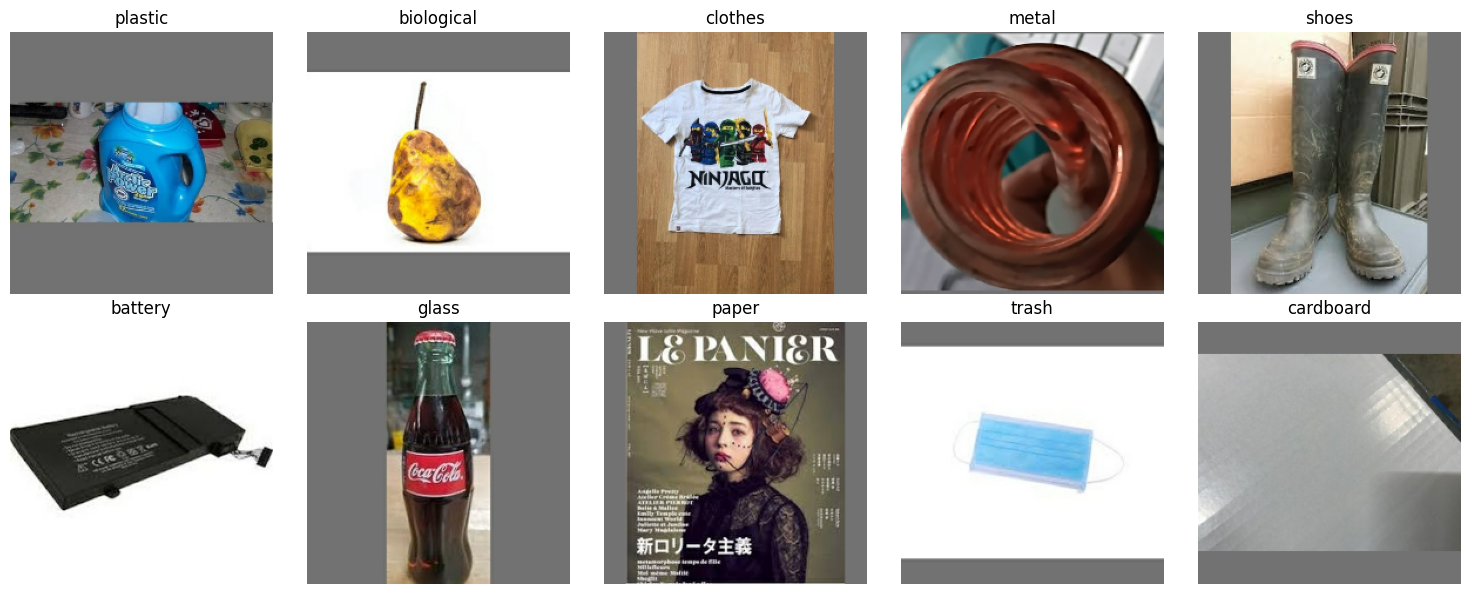

In [9]:
raw_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

class_names = raw_data.class_names

shown_classes = set()
j = 0

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for images, labels in raw_data:
    for i in range(len(images)):
        label_index = labels[i].numpy()
        label_name = class_names[label_index]

        if label_name not in shown_classes:

            img_display = images[i].numpy().astype("uint8")

            axes[j].imshow(img_display)
            axes[j].axis("off")
            axes[j].set_title(label_name)

            shown_classes.add(label_name)
            j += 1

            if j == 10 or j >= len(class_names):
                break
    if j == 10 or j >= len(class_names):
        break

plt.tight_layout()
plt.show()

**Statistik Dataset Sampah**

Statistik Jumlah Sampah Seluruhnya

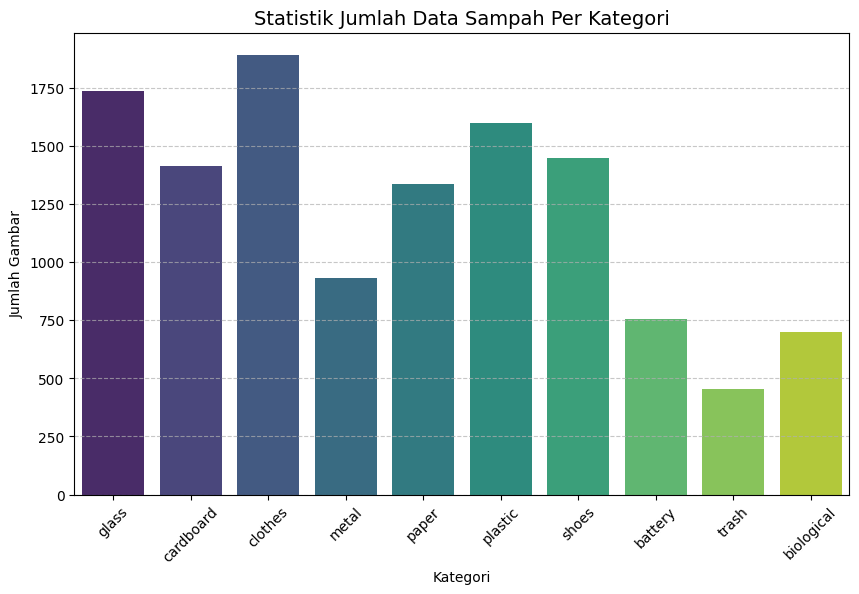

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_stats, x='Kategori', y='Jumlah Gambar', hue='Kategori', palette='viridis', legend=False)
plt.title('Statistik Jumlah Data Sampah Per Kategori', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Matrix Korelasi Antar Warna**

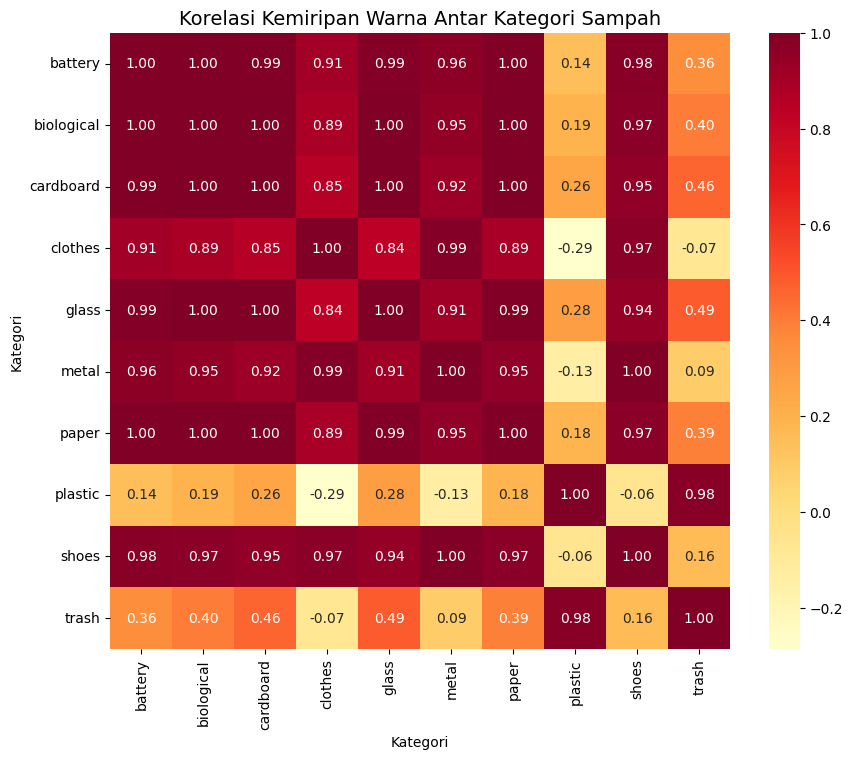

In [13]:
def extract_color_features(dataset_path):
    all_features = []
    categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for category in categories:
        cat_path = os.path.join(dataset_path, category)
        # Ambil sampel gambar
        image_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:50]

        for img_name in image_files:
            img = cv2.imread(os.path.join(cat_path, img_name))
            if img is None: continue

            # Ekstrak rata-rata warna RGB
            avg_color = cv2.mean(img)[:3]

            all_features.append({
                'Kategori': category,
                'Red': avg_color[2],
                'Green': avg_color[1],
                'Blue': avg_color[0]
            })

    return pd.DataFrame(all_features)

df_color = extract_color_features(dataset_path)
df_color_grouped = df_color.groupby('Kategori').mean()


corr_color = df_color_grouped.T.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_color, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Korelasi Kemiripan Warna Antar Kategori Sampah', fontsize=14)
plt.show()

Visualisasi ini menunjukkan bahwa dataset kamu memiliki **keragaman objek** yang baik namun dengan tantangan **ketidakseimbangan jumlah** (*imbalance*) yang cukup mencolok antara kelas mayoritas seperti *clothes* dan kelas minoritas seperti *trash*. Melalui matriks korelasi, terlihat adanya **kemiripan fitur warna** yang sangat kuat antar kategori (seperti *glass*, *paper*, dan *cardboard*), yang menandakan bahwa model tidak bisa hanya mengandalkan warna saja tetapi harus mempelajari detail bentuk dan tekstur untuk membedakan kategori tersebut secara akurat.